<a href="https://colab.research.google.com/github/LouisFOU/Solar-Panel-Detection/blob/main/FirstFinetuneTry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/IBM/terratorch.git
%cd terratorch
!pip install -e .

fatal: destination path 'terratorch' already exists and is not an empty directory.
/content/terratorch
Obtaining file:///content/terratorch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for terratorch (pyproject.toml) ... done
  Created wheel for terratorch: filename=terratorch-1.2.6-0.editable-py3-none-any.whl size=11922 sha256=711b929e22ad059065499a6db3ed1a8def853fba2c5ebcbfed891a77c6fc5328
  Stored in directory: /tmp/pip-ephem-wheel-cache-qipi0v5x/wheels/73/7b/2c/56d90344bb6c98b369f82de3b548797e458d7ad06555c14a12
Successfully built terratorch
  Attempting uninstall: terratorch
    Found existing installation: terratorch 1.2.6
    Uninstalling terratorch-1.2.6:
      Successfully uninstalled terratorch-1.2.6


In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

!mkdir -p /content/data_local

!unzip -q "/content/drive/MyDrive/m-pv4ger-seg/data.zip" -d "/content/data_local"


nb_fichiers = len([f for f in os.listdir('/content/data_local') if f.endswith('.hdf5')])
print(f"Parfait, {nb_fichiers} tuiles HDF5 ont été extraites avec succès !")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/data_local/5.900363,51.017229.hdf5? [y]es, [n]o, [A]ll, [N]one, [r]ename: Parfait, 4027 tuiles HDF5 ont été extraites avec succès !


In [3]:
!pip install lightning

In [4]:
import os
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl

class PV4GERDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.file_names = [f for f in os.listdir(data_dir) if f.endswith('.hdf5')]

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_names[idx])

        with h5py.File(file_path, 'r') as f:
            # On extrait l'image et le masque depuis le fichier HDF5
            image = torch.tensor(f['image'][:]).float()
            mask = torch.tensor(f['mask'][:]).long()

        return image, mask

class PV4GERDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=8, num_workers=2):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.dataset = PV4GERDataset(self.data_dir)

    def train_dataloader(self):
        # On mélange les données à chaque epoch pour un apprentissage robuste
        return DataLoader(self.dataset, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True)

In [5]:
import os
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import terratorch.models
from terratorch.tasks import SemanticSegmentationTask
from lightning.pytorch import Trainer
import gc

# Vidage de la mémoire résiduelle
torch.cuda.empty_cache()
gc.collect()

class PV4GERDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.file_names = [f for f in os.listdir(data_dir) if f.endswith('.hdf5')]

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_names[idx])
        with h5py.File(file_path, 'r') as f:
            cles = list(f.keys())
            cle_image = next((k for k in cles if k.lower() in ['image', 'img', 'data', 'x']), cles[0])
            cle_masque = next((k for k in cles if k.lower() in ['mask', 'label', 'gt', 'y']), cles[-1])

            image = torch.tensor(f[cle_image][:]).float()
            mask = torch.tensor(f[cle_masque][:]).long()

        # Formatage des dimensions
        if image.ndim == 2:
            image = image.unsqueeze(0)
        elif image.ndim == 3:
            if image.shape[2] <= 10:
                image = image.permute(2, 0, 1)

        C, H, W = image.shape
        if C < 6:
            bandes_manquantes = torch.zeros(6 - C, H, W)
            image = torch.cat([image, bandes_manquantes], dim=0)
        elif C > 6:
            image = image[:6]

        image = image.unsqueeze(1)

        if mask.ndim > 2:
            mask = mask.squeeze()

        return {"image": image, "mask": mask}

class PV4GERDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=2, num_workers=2):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        self.dataset = PV4GERDataset(self.data_dir)

    def train_dataloader(self):
        return DataLoader(self.dataset, batch_size=self.batch_size, num_workers=self.num_workers, shuffle=True)

data_module = PV4GERDataModule(data_dir="/content/data_local", batch_size=2)


task = SemanticSegmentationTask(
    model_args={
        "backbone": "prithvi_eo_v2_300",
        "decoder": "FCNDecoder",
        "num_classes": 2
    },
    model_factory="EncoderDecoderFactory",
    loss="ce",
    ignore_index=-1,
    lr=1e-4
)

trainer = Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=3,
    log_every_n_steps=10
)

trainer.fit(model=task, datamodule=data_module)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


1/3 - Préparation des données (Batch réduit pour éviter la saturation)...
2/3 - Initialisation de Prithvi et de la Tâche...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

3/3 - Démarrage de l'entraînement...


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Trainable params: 308 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 308 M                                                                                                
Total estimated model params size (MB): 1.2 K                                                                      
Modules in train mode: 602                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: The ``compute`` method of
metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, as metric states have 
not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=3` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


In [15]:
import torch
import os


save_dir = "/content/drive/MyDrive/Prithvi_Project_Weights"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "pv4ger_prithvi.pth")

torch.save(task.model.state_dict(), save_path)

print(f"Saved here : {save_path}")

Saved here : /content/drive/MyDrive/Prithvi_Project_Weights/pv4ger_prithvi.pth


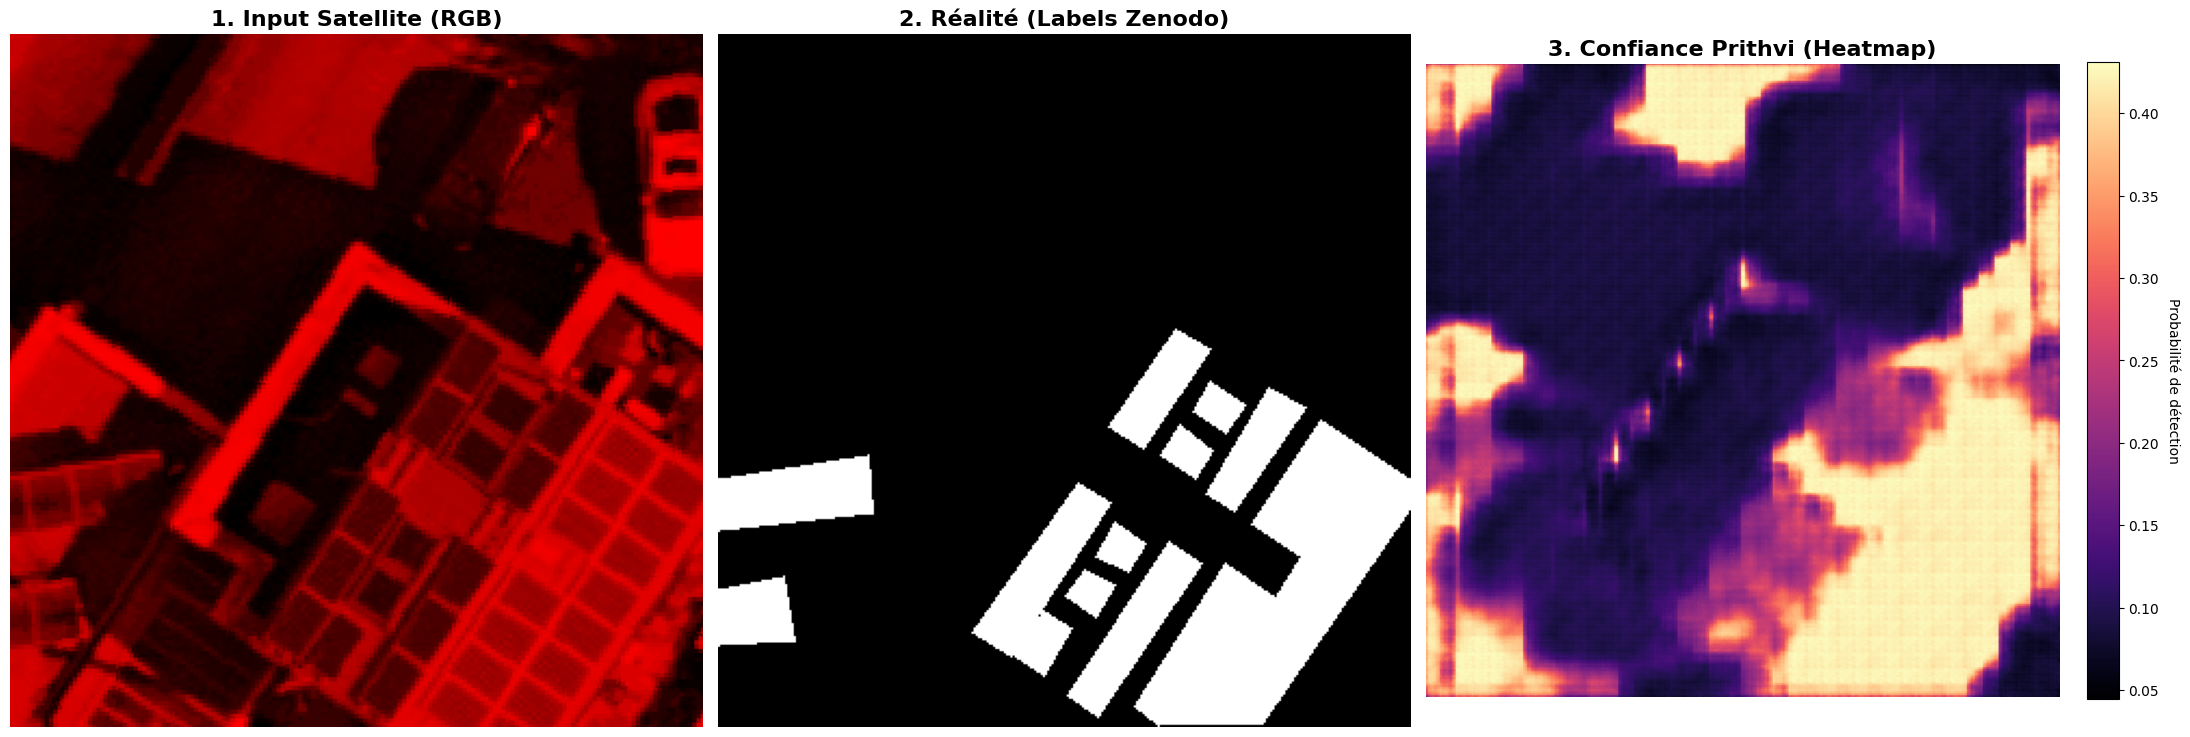

In [25]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn.functional as F

# 1. Mise en mode évaluation
task.eval()
torch.set_grad_enabled(False)

# 2. Récupération d'un échantillon
# Si le résultat n'est pas probant, relance cette cellule pour tester une autre image
batch = next(iter(data_module.train_dataloader()))
images = batch["image"]
masks = batch["mask"]

# 3. Inférence (Passage dans Prithvi)
outputs = task(images.to(task.device))

# Extraction automatique du tenseur (gestion des objets ModelOutput)
prediction_tensor = None
if hasattr(outputs, '__dict__'):
    for val in outputs.__dict__.values():
        if torch.is_tensor(val):
            prediction_tensor = val
            break
if prediction_tensor is None:
    prediction_tensor = outputs[0] if isinstance(outputs, (list, tuple)) else outputs

# Calcul de la Heatmap (Probabilités)
# On utilise Softmax pour transformer les scores bruts en probabilités (0 à 1)
probs = F.softmax(prediction_tensor, dim=1)
heatmap = probs[0, 1, :, :].cpu().numpy() # On prend la classe 1 (Panneaux)

# 4. Affichage du Montage Final
fig, ax = plt.subplots(1, 3, figsize=(22, 8))

# --- Colonne 1 : Image Satellite (RGB) ---
# On tente une reconstruction RGB plus propre
img_display = images[0, 0:3, 0, :, :].permute(1, 2, 0).cpu().numpy()
for i in range(3):
    channel = img_display[:,:,i]
    # Normalisation Min-Max par canal pour la clarté visuelle
    img_display[:,:,i] = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)

ax[0].imshow(img_display)
ax[0].set_title("1. Input Satellite (RGB)", fontsize=16, fontweight='bold')
ax[0].axis('off')

# --- Colonne 2 : Vérité Terrain (Ground Truth) ---
ax[1].imshow(masks[0].cpu().numpy(), cmap='gray')
ax[1].set_title("2. Réalité (Labels Zenodo)", fontsize=16, fontweight='bold')
ax[1].axis('off')

# --- Colonne 3 : Intelligence du Modèle (Heatmap) ---
# Magma est une colormap qui fait ressortir les zones de "chaleur" (jaune = haute confiance)
im = ax[2].imshow(heatmap, cmap='magma')
ax[2].set_title("3. Confiance Prithvi (Heatmap)", fontsize=16, fontweight='bold')
ax[2].axis('off')

# Ajout d'une barre de légende pour le niveau de confiance
plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04).set_label('Probabilité de détection', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()
